In [3]:
import subprocess, sys

# Install extras (idempotent)
for pkg in ["xgboost", "shap"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap

# ── Plotting defaults ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.facecolor": "white", "figure.dpi": 100})
PALETTE       = ["#2ecc71", "#e74c3c"]       # green = healthy, red = disease
MODEL_COLORS  = ["#3498db", "#9b59b6", "#e67e22"]

import sklearn
print("✅ All libraries loaded successfully!")
print(f"   numpy   {np.__version__}")
print(f"   pandas  {pd.__version__}")
print(f"   sklearn {sklearn.__version__}")


✅ All libraries loaded successfully!
   numpy   2.4.6
   pandas  3.0.3
   sklearn 1.9.0


In [4]:
URL = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df = pd.read_csv(URL)
print(f"Dataset loaded → {df.shape[0]} rows, {df.shape[1]} columns")
df.head(8)


Dataset loaded → 303 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1


In [5]:
# Feature reference guide
feature_guide = pd.DataFrame({
    "Feature" : ["age","sex","cp","trestbps","chol","fbs",
                 "restecg","thalach","exang","oldpeak","slope","ca","thal","target"],
    "Type"    : ["Continuous","Binary","Categorical","Continuous","Continuous","Binary",
                 "Categorical","Continuous","Binary","Continuous","Ordinal","Ordinal",
                 "Categorical","Binary"],
    "Description": [
        "Age in years",
        "Sex  (1 = Male, 0 = Female)",
        "Chest Pain Type  (0 = Typical Angina, 1 = Atypical, 2 = Non-Anginal, 3 = Asymptomatic)",
        "Resting Blood Pressure (mmHg at admission)",
        "Serum Cholesterol (mg/dL)",
        "Fasting Blood Sugar > 120 mg/dL  (1 = True, 0 = False)",
        "Resting ECG Results  (0 = Normal, 1 = ST-T wave abnormality, 2 = LVH by Estes criteria)",
        "Maximum Heart Rate Achieved during exercise (bpm)",
        "Exercise-Induced Angina  (1 = Yes, 0 = No)",
        "ST Depression induced by exercise relative to rest",
        "Slope of Peak Exercise ST Segment  (0 = Upsloping, 1 = Flat, 2 = Downsloping)",
        "Number of Major Vessels Colored by Fluoroscopy  (0–3)",
        "Thalassemia  (1 = Normal, 2 = Fixed Defect, 3 = Reversible Defect)",
        "Heart Disease Present  (1 = Yes, 0 = No)  ← TARGET"
    ]
})
feature_guide


,Feature,Type,Description
0,age,Continuous,Age in years
1,sex,Binary,"Sex (1 = Male, 0 = Female)"
2,cp,Categorical,"Chest Pain Type (0 = Typical Angina, 1 = Atyp..."
3,trestbps,Continuous,Resting Blood Pressure (mmHg at admission)
4,chol,Continuous,Serum Cholesterol (mg/dL)
5,fbs,Binary,"Fasting Blood Sugar > 120 mg/dL (1 = True, 0 ..."
6,restecg,Categorical,"Resting ECG Results (0 = Normal, 1 = ST-T wav..."
7,thalach,Continuous,Maximum Heart Rate Achieved during exercise (bpm)
8,exang,Binary,"Exercise-Induced Angina (1 = Yes, 0 = No)"
9,oldpeak,Continuous,ST Depression induced by exercise relative to ...


In [6]:
print("=" * 52)
print("  DATA HEALTH CHECK")
print("=" * 52)
print(f"  Rows              : {df.shape[0]}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Missing values    : {df.isnull().sum().sum()}")
print(f"  Duplicate rows    : {df.duplicated().sum()}")
print(f"  Memory usage      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 52)
print()
print("NULL COUNTS PER FEATURE:")
print(df.isnull().sum().to_string())


  DATA HEALTH CHECK
  Rows              : 303
  Columns           : 14
  Missing values    : 0
  Duplicate rows    : 1
  Memory usage      : 33.3 KB

NULL COUNTS PER FEATURE:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


In [7]:
# Remove any duplicates
df.drop_duplicates(inplace=True)
print(f"After deduplication → {df.shape[0]} rows retained\n")

# Statistical summary
df.describe().round(2)


After deduplication → 302 rows retained



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.42,0.68,0.96,131.60,246.50,0.15,0.53,149.57,0.33,1.04,1.40,0.72,2.31,0.54
std,9.05,0.47,1.03,17.56,51.75,0.36,0.53,22.90,0.47,1.16,0.62,1.01,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.50,1.00,1.00,130.00,240.50,0.00,1.00,152.50,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.75,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [8]:
# Data types & value ranges
print("Feature value ranges (key clinical checks):")
print("-" * 55)
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"  {col:<12}  range: [{df[col].min():>7.2f}, {df[col].max():>7.2f}]   "
          f"unique: {unique_vals}")


Feature value ranges (key clinical checks):
-------------------------------------------------------
  age           range: [  29.00,   77.00]   unique: 41
  sex           range: [   0.00,    1.00]   unique: 2
  cp            range: [   0.00,    3.00]   unique: 4
  trestbps      range: [  94.00,  200.00]   unique: 49
  chol          range: [ 126.00,  564.00]   unique: 152
  fbs           range: [   0.00,    1.00]   unique: 2
  restecg       range: [   0.00,    2.00]   unique: 3
  thalach       range: [  71.00,  202.00]   unique: 91
  exang         range: [   0.00,    1.00]   unique: 2
  oldpeak       range: [   0.00,    6.20]   unique: 40
  slope         range: [   0.00,    2.00]   unique: 3
  ca            range: [   0.00,    4.00]   unique: 5
  thal          range: [   0.00,    3.00]   unique: 4
  target        range: [   0.00,    1.00]   unique: 2


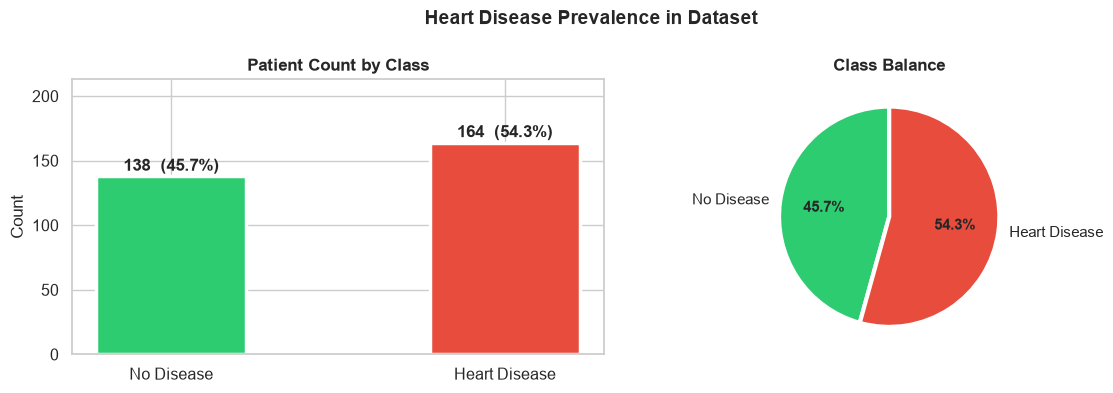

Class imbalance: 8.6% difference — dataset is well-balanced.
No SMOTE or class-weighting required for this scale.


In [9]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["target"].value_counts().sort_index()
labels = ["No Disease", "Heart Disease"]

# Bar chart
bars = axes[0].bar(labels, counts.values, color=PALETTE, width=0.45,
                   edgecolor="white", linewidth=2.5)
for bar, n in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1.5,
                 f"{n}  ({n/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, max(counts.values) * 1.3)
axes[0].set_title("Patient Count by Class", fontweight="bold")
axes[0].set_ylabel("Count")

# Pie
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=PALETTE, autopct="%1.1f%%",
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 3},
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1].set_title("Class Balance", fontweight="bold")

plt.suptitle("Heart Disease Prevalence in Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

imbalance = abs(counts[0] - counts[1]) / len(df) * 100
print(f"Class imbalance: {imbalance:.1f}% difference — dataset is well-balanced.")
print("No SMOTE or class-weighting required for this scale.")


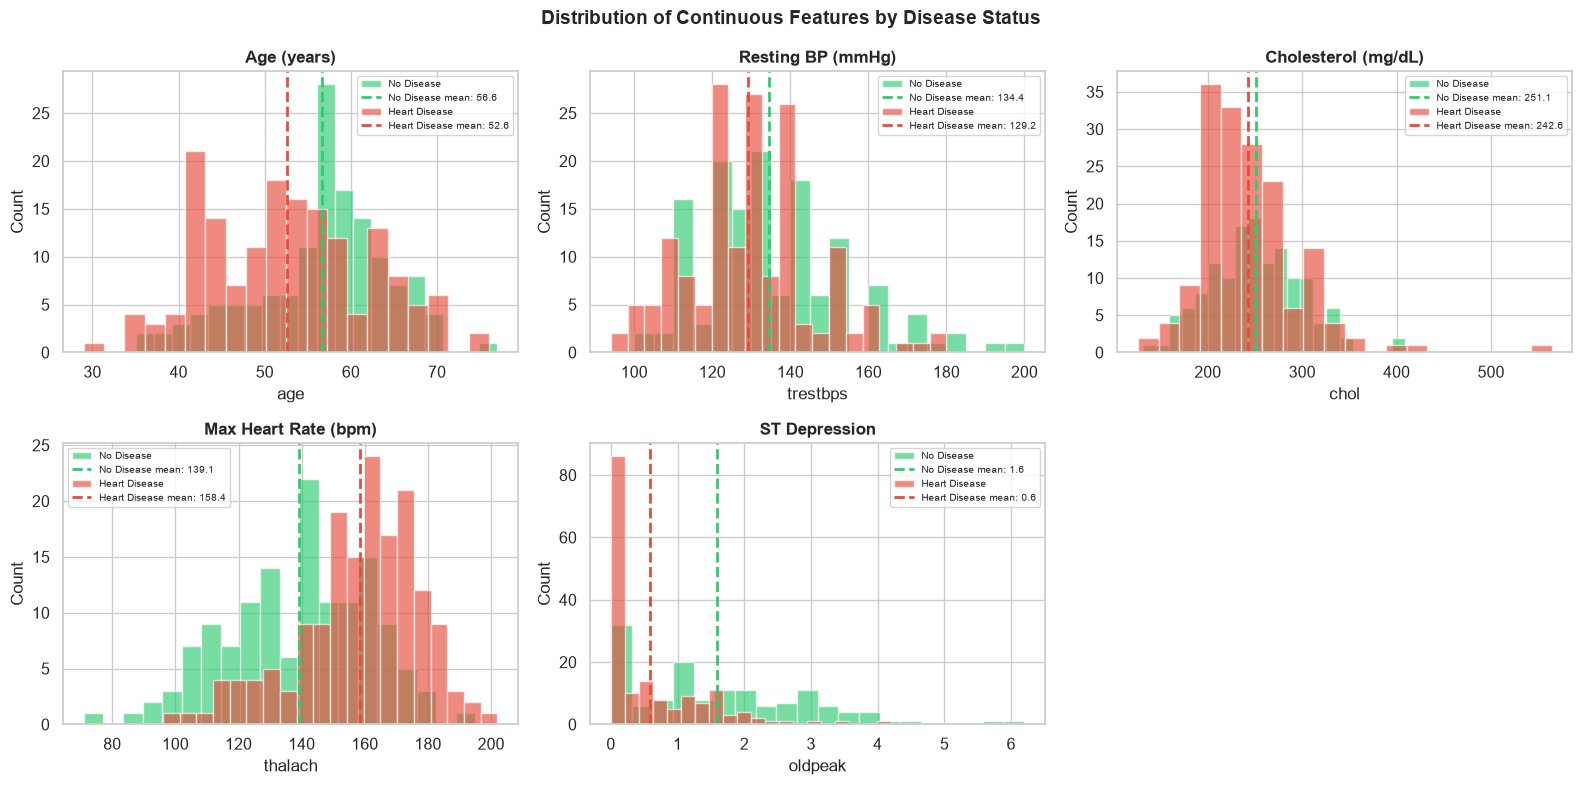

In [10]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
col_labels = {
    "age":      "Age (years)",
    "trestbps": "Resting BP (mmHg)",
    "chol":     "Cholesterol (mg/dL)",
    "thalach":  "Max Heart Rate (bpm)",
    "oldpeak":  "ST Depression"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for val, label, c in [(0, "No Disease", "#2ecc71"), (1, "Heart Disease", "#e74c3c")]:
        data = df[df["target"] == val][col]
        axes[i].hist(data, bins=20, alpha=0.65, color=c, label=label, edgecolor="white")
        axes[i].axvline(data.mean(), color=c, linestyle="--", linewidth=2,
                        label=f"{label} mean: {data.mean():.1f}")
    axes[i].set_title(col_labels[col], fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=7)

fig.delaxes(axes[5])
plt.suptitle("Distribution of Continuous Features by Disease Status",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


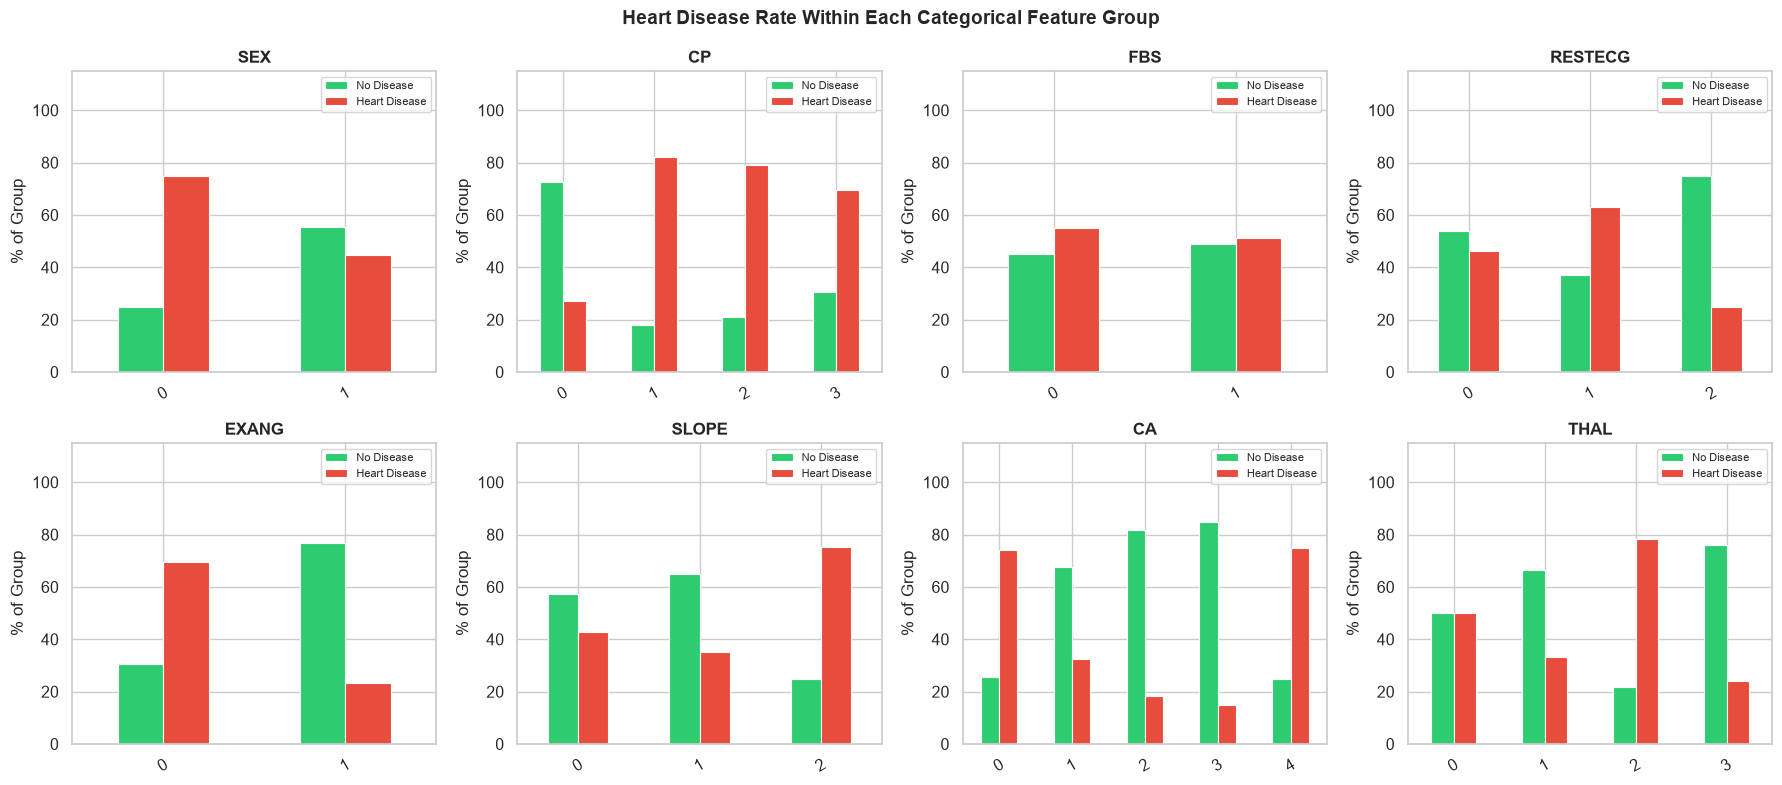

In [11]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["target"], normalize="index") * 100
    ct.columns = ["No Disease", "Heart Disease"]
    ct.plot(kind="bar", ax=axes[i], color=PALETTE, edgecolor="white", linewidth=0.8)
    axes[i].set_title(col.upper(), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% of Group")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, 115)

plt.suptitle("Heart Disease Rate Within Each Categorical Feature Group",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


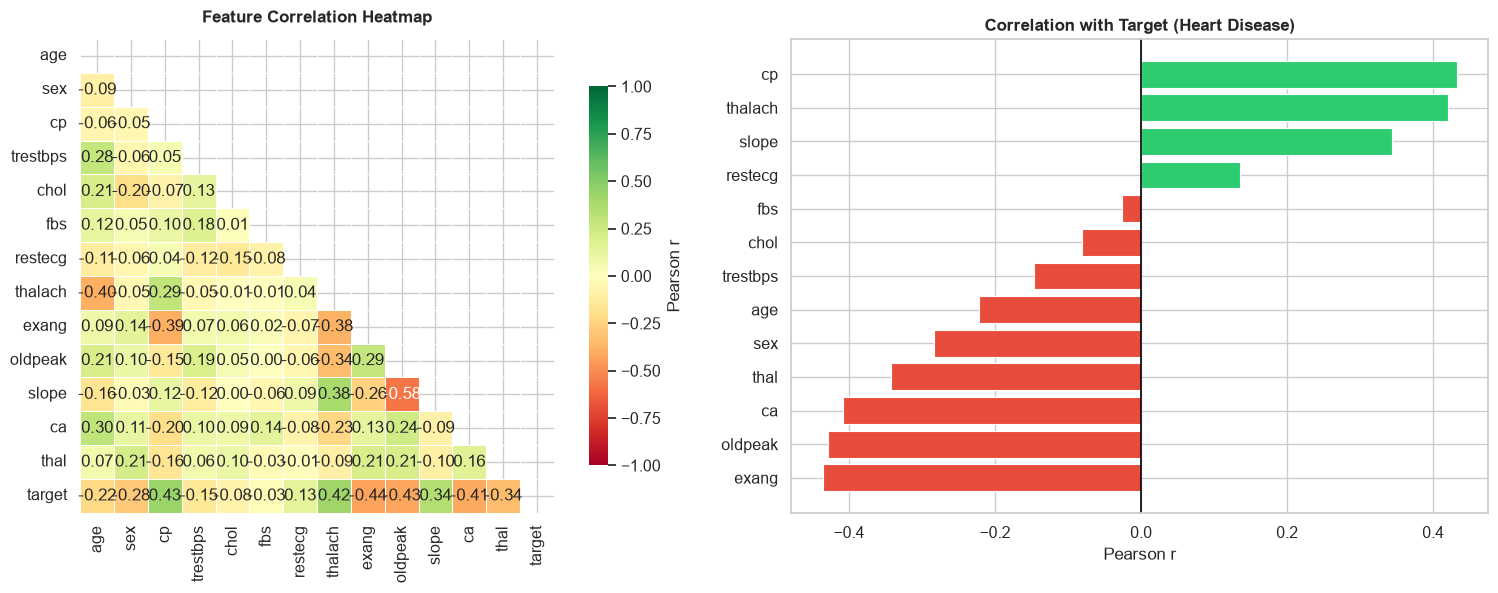


Top 5 features by absolute correlation with target:
exang      0.436
cp         0.432
oldpeak    0.429
thalach    0.420
ca         0.409


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
axes[0].set_title("Feature Correlation Heatmap", fontweight="bold", pad=12)

# Correlation with target (bar)
target_corr = df.corr()["target"].drop("target").sort_values()
bar_colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in target_corr]
axes[1].barh(target_corr.index, target_corr.values,
             color=bar_colors, edgecolor="white", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=1.2)
axes[1].set_title("Correlation with Target (Heart Disease)", fontweight="bold")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("\nTop 5 features by absolute correlation with target:")
print(target_corr.abs().sort_values(ascending=False).head(5).round(3).to_string())


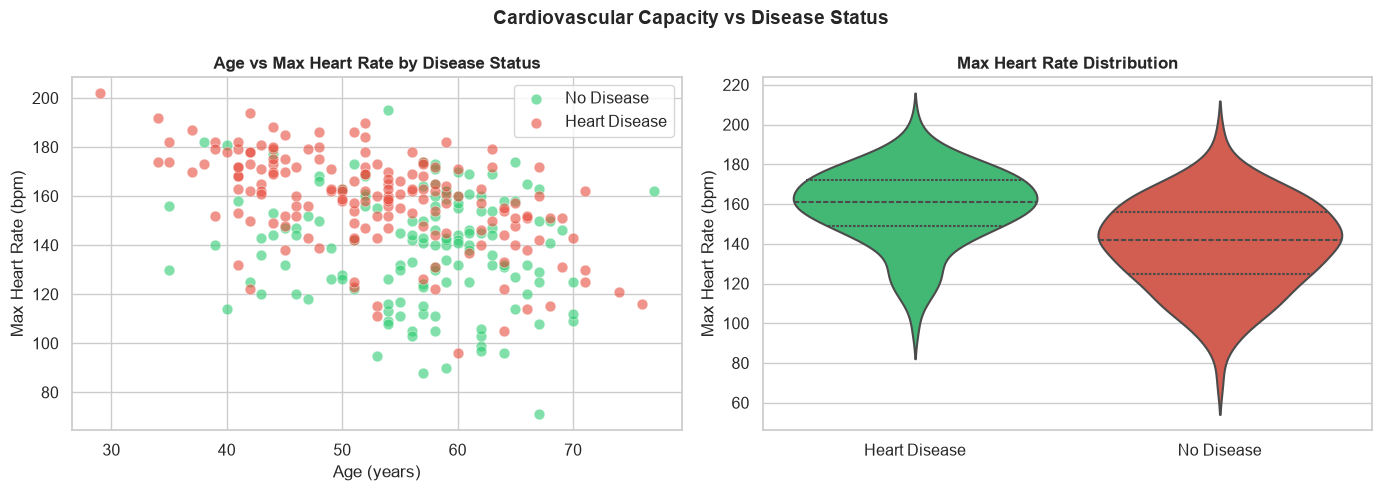


💡 Insight: No Disease mean HR = 139.1 bpm  vs  Heart Disease mean HR = 158.4 bpm
   Lower max heart rate signals reduced cardiovascular reserve — a key clinical indicator.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Age vs thalach, colored by target
for val, label, c in [(0, "No Disease", "#2ecc71"), (1, "Heart Disease", "#e74c3c")]:
    subset = df[df["target"] == val]
    axes[0].scatter(subset["age"], subset["thalach"], c=c, label=label,
                    alpha=0.6, s=60, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Max Heart Rate (bpm)")
axes[0].set_title("Age vs Max Heart Rate by Disease Status", fontweight="bold")
axes[0].legend()

# Violin: thalach distribution
df_plot = df.copy()
df_plot["Status"] = df_plot["target"].map({0: "No Disease", 1: "Heart Disease"})
sns.violinplot(data=df_plot, x="Status", y="thalach", palette=PALETTE,
               ax=axes[1], inner="quartile", linewidth=1.5)
axes[1].set_title("Max Heart Rate Distribution", fontweight="bold")
axes[1].set_ylabel("Max Heart Rate (bpm)")
axes[1].set_xlabel("")

plt.suptitle("Cardiovascular Capacity vs Disease Status", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

no_dis_mean = df[df["target"]==0]["thalach"].mean()
dis_mean    = df[df["target"]==1]["thalach"].mean()
print(f"\n💡 Insight: No Disease mean HR = {no_dis_mean:.1f} bpm  vs  "
      f"Heart Disease mean HR = {dis_mean:.1f} bpm")
print("   Lower max heart rate signals reduced cardiovascular reserve — a key clinical indicator.")


In [14]:
df_eng = df.copy()

# 1. Age group stratification (0=<40, 1=40-50, 2=50-60, 3=60+)
df_eng["age_group"] = pd.cut(
    df_eng["age"], bins=[0, 40, 50, 60, 100], labels=[0, 1, 2, 3]
).astype(int)

# 2. Heart rate reserve (theoretical max HR minus achieved)
df_eng["hr_reserve"] = (220 - df_eng["age"]) - df_eng["thalach"]

# 3. Silent ischemia flag (asymptomatic CP is paradoxically the riskiest)
df_eng["silent_ischemia"] = (df_eng["cp"] == 0).astype(int)

# 4. Hypertension flag (Stage-2: BP >= 140 mmHg)
df_eng["hypertension"] = (df_eng["trestbps"] >= 140).astype(int)

# 5. ST risk score (composite: depression × slope direction)
df_eng["st_risk"] = df_eng["oldpeak"] * df_eng["slope"]

engineered = ["age_group", "hr_reserve", "silent_ischemia", "hypertension", "st_risk"]
print(f"Added {len(engineered)} engineered features. New shape: {df_eng.shape}")
print()
print("Engineered features summary:")
df_eng[engineered].describe().round(3)


Added 5 engineered features. New shape: (302, 19)

Engineered features summary:


,age_group,hr_reserve,silent_ischemia,hypertension,st_risk
count,302.000,302.000,302.000,302.000,302.000
mean,1.891,16.010,0.474,0.321,1.046
std,0.861,21.039,0.500,0.468,1.242
min,0.000,-29.000,0.000,0.000,0.000
25%,1.000,0.000,0.000,0.000,0.000
50%,2.000,12.000,0.000,0.000,0.600
75%,3.000,28.000,1.000,1.000,1.800
max,3.000,82.000,1.000,1.000,8.000


In [15]:
X = df_eng.drop("target", axis=1)
y = df_eng["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Test samples      : {X_test.shape[0]}")
print(f"Total features    : {X_train.shape[1]}  (13 original + 5 engineered)")
print()
print("Class balance in training set:")
train_counts = y_train.value_counts().rename({0: "No Disease", 1: "Heart Disease"})
print(train_counts.to_string())
print()
print("Class balance in test set:")
test_counts = y_test.value_counts().rename({0: "No Disease", 1: "Heart Disease"})
print(test_counts.to_string())


Training samples  : 241
Test samples      : 61
Total features    : 18  (13 original + 5 engineered)

Class balance in training set:
target
Heart Disease    131
No Disease       110

Class balance in test set:
target
Heart Disease    33
No Disease       28


In [16]:
# Define pipelines (scaler inside pipeline = no leakage)
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, C=0.1,
                                      solver="lbfgs", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=200, max_depth=6,
                                          min_samples_leaf=2, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  eval_metric="logloss", random_state=42, verbosity=0))
    ])
}

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("5-Fold Stratified Cross-Validation  (AUC-ROC scoring)")
print("-" * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22}  {scores.mean():.4f}  ±  {scores.std():.4f}")
print("-" * 55)


5-Fold Stratified Cross-Validation  (AUC-ROC scoring)
-------------------------------------------------------
  Logistic Regression     0.8958  ±  0.0517
  Random Forest           0.8905  ±  0.0618
  XGBoost                 0.8963  ±  0.0565
-------------------------------------------------------


In [18]:
# Train all models on the full training set
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("All 3 models trained on full training set.")


All 3 models trained on full training set.


In [20]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model"       : name,
        "Accuracy"    : accuracy_score(y_test, y_pred),
        "F1-Score"    : f1_score(y_test, y_pred),
        "AUC-ROC"     : roc_auc_score(y_test, y_prob),
        "CV AUC Mean" : cv_results[name].mean(),
        "CV AUC Std"  : cv_results[name].std()
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
best = results_df["AUC-ROC"].idxmax()

print("Test Set Performance:")
print(results_df.to_string())
print(f"\n Best model (by AUC-ROC): {best}  [{results_df.loc[best, 'AUC-ROC']:.4f}]")


Test Set Performance:
                     Accuracy  F1-Score  AUC-ROC  CV AUC Mean  CV AUC Std
Model                                                                    
Logistic Regression    0.7869    0.8169   0.8745       0.8958      0.0517
Random Forest          0.8197    0.8493   0.8874       0.8905      0.0618
XGBoost                0.7869    0.8219   0.8571       0.8963      0.0565

 Best model (by AUC-ROC): Random Forest  [0.8874]


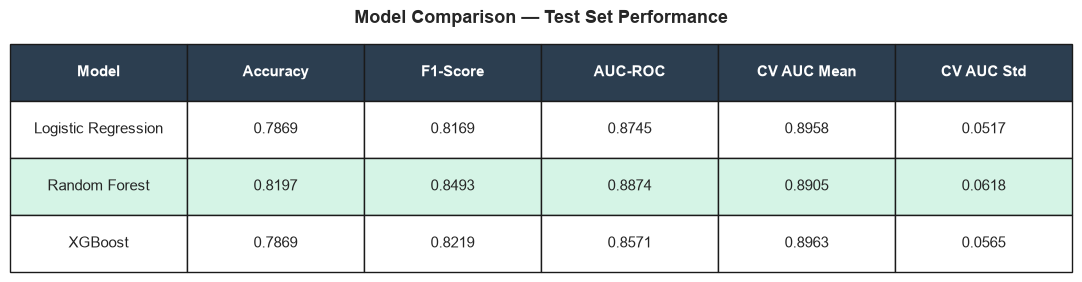

In [21]:
# Visual performance table
fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

metrics_show = ["Accuracy", "F1-Score", "AUC-ROC", "CV AUC Mean", "CV AUC Std"]
table_vals   = results_df[metrics_show].reset_index().values.tolist()
col_labels   = ["Model"] + metrics_show

tbl = ax.table(cellText=table_vals, colLabels=col_labels,
               cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

for j in range(len(col_labels)):            # header row styling
    tbl[0, j].set_facecolor("#2c3e50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

best_row_idx = list(results_df.index).index(best) + 1
for j in range(len(col_labels)):            # highlight best model
    tbl[best_row_idx, j].set_facecolor("#d5f4e6")

ax.set_title("Model Comparison — Test Set Performance",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


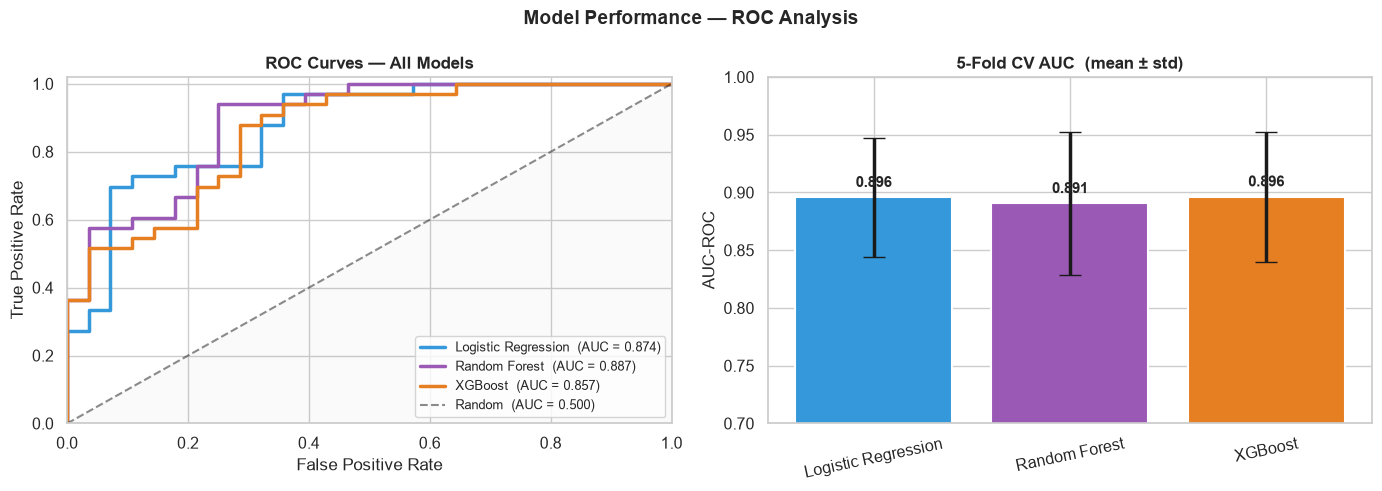

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for (name, model), c in zip(trained_models.items(), MODEL_COLORS):
    y_prob      = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=c, lw=2.5, label=f"{name}  (AUC = {auc:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=1.5, alpha=0.5, label="Random  (AUC = 0.500)")
axes[0].fill_between([0,1],[0,1], alpha=0.04, color="gray")
axes[0].set_xlabel("False Positive Rate");  axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].set_xlim([0,1]);  axes[0].set_ylim([0,1.02])

# CV AUC bar with error bars
cv_means = [cv_results[m].mean() for m in trained_models]
cv_stds  = [cv_results[m].std()  for m in trained_models]
bars = axes[1].bar(list(trained_models.keys()), cv_means, yerr=cv_stds,
                    color=MODEL_COLORS, capsize=8, edgecolor="white", linewidth=1.5,
                    error_kw={"linewidth": 2.5})
for bar, m in zip(bars, cv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.009,
                 f"{m:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylim(0.70, 1.00)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("5-Fold CV AUC  (mean ± std)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=12)

plt.suptitle("Model Performance — ROC Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


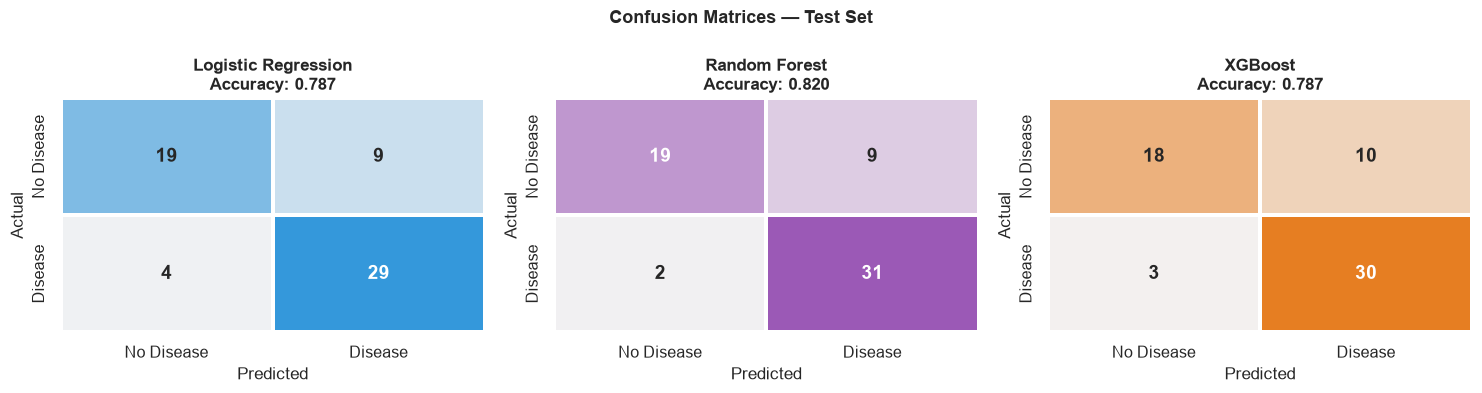

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model), c in zip(axes, trained_models.items(), MODEL_COLORS):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cmap   = sns.light_palette(c, as_cmap=True)

    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=cmap,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                linewidths=1.5, linecolor="white", cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.3f}", fontweight="bold")
    ax.set_xlabel("Predicted");  ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [24]:
best_model  = trained_models[best]
y_pred_best = best_model.predict(X_test)

print(f"Detailed Classification Report — {best}")
print("=" * 55)
print(classification_report(y_test, y_pred_best,
                             target_names=["No Disease", "Heart Disease"]))
print("=" * 55)
print("Recall (Sensitivity) on Heart Disease class is critical in clinical settings.")
print("False Negatives (missed disease) are costlier than False Positives.")


Detailed Classification Report — Random Forest
               precision    recall  f1-score   support

   No Disease       0.90      0.68      0.78        28
Heart Disease       0.78      0.94      0.85        33

     accuracy                           0.82        61
    macro avg       0.84      0.81      0.81        61
 weighted avg       0.83      0.82      0.82        61

Recall (Sensitivity) on Heart Disease class is critical in clinical settings.
False Negatives (missed disease) are costlier than False Positives.


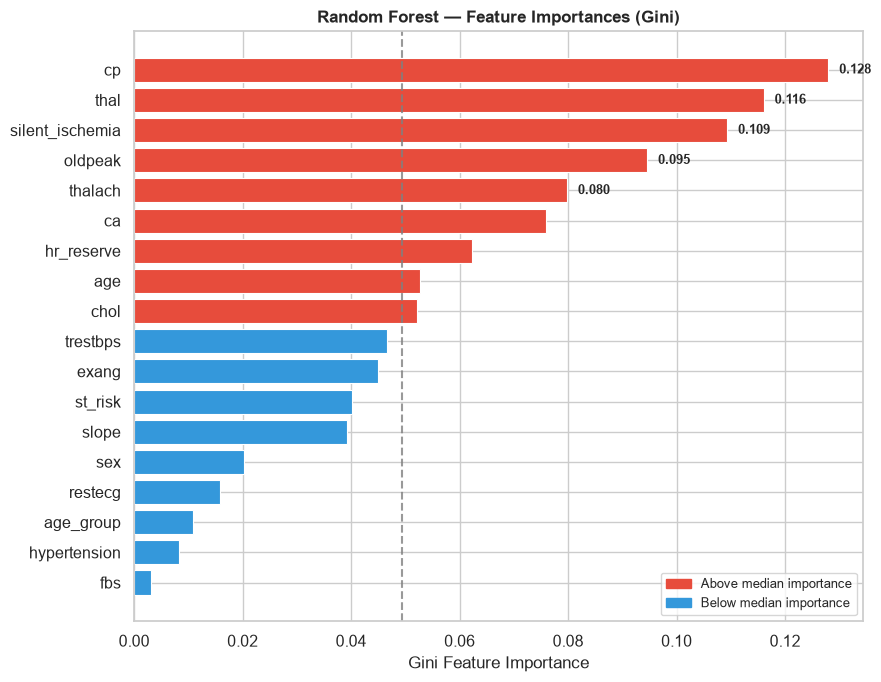

In [25]:
rf_clf     = trained_models["Random Forest"].named_steps["clf"]
feat_imp   = pd.Series(rf_clf.feature_importances_, index=X.columns)
feat_sorted = feat_imp.sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
bar_cols = ["#e74c3c" if v >= feat_imp.median() else "#3498db"
            for v in feat_sorted.values]

bars = ax.barh(feat_sorted.index, feat_sorted.values,
               color=bar_cols, edgecolor="white", linewidth=0.8)
ax.axvline(feat_imp.median(), color="gray", linestyle="--", alpha=0.8, linewidth=1.5)

for bar, val in zip(bars[-5:], feat_sorted.values[-5:]):   # annotate top 5
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

p1 = mpatches.Patch(color="#e74c3c", label="Above median importance")
p2 = mpatches.Patch(color="#3498db", label="Below median importance")
ax.legend(handles=[p1, p2], loc="lower right", fontsize=9)

ax.set_xlabel("Gini Feature Importance")
ax.set_title("Random Forest — Feature Importances (Gini)", fontweight="bold")
plt.tight_layout()
plt.show()


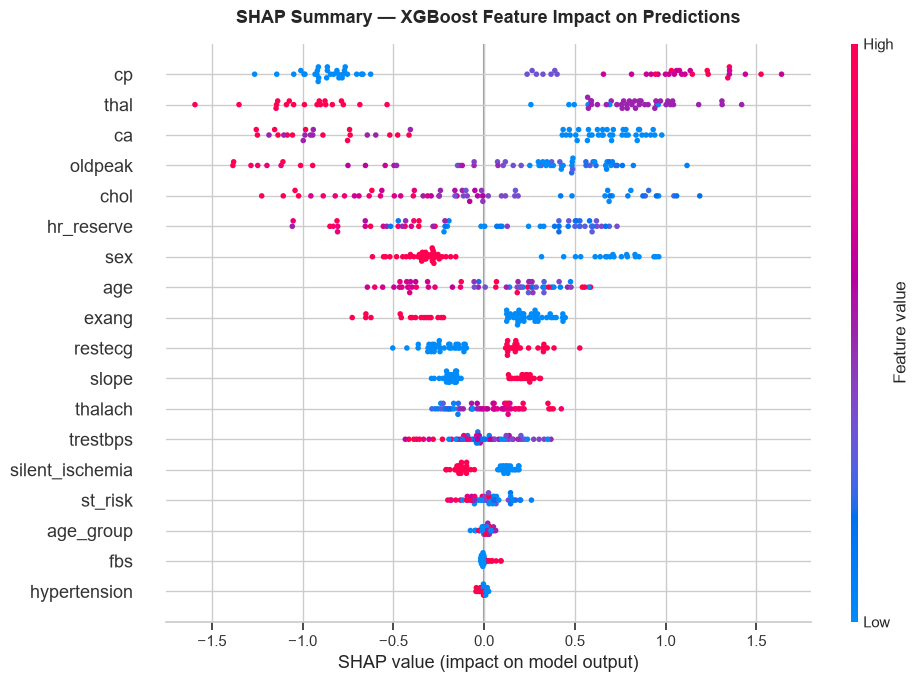

In [26]:
xgb_pipeline  = trained_models["XGBoost"]
xgb_clf       = xgb_pipeline.named_steps["clf"]
scaler        = xgb_pipeline.named_steps["scaler"]
X_test_scaled = scaler.transform(X_test)

explainer    = shap.TreeExplainer(xgb_clf)
shap_values  = explainer.shap_values(X_test_scaled)

# Beeswarm summary
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=list(X.columns),
                  show=False, plot_size=None)
plt.title("SHAP Summary — XGBoost Feature Impact on Predictions",
          fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.show()


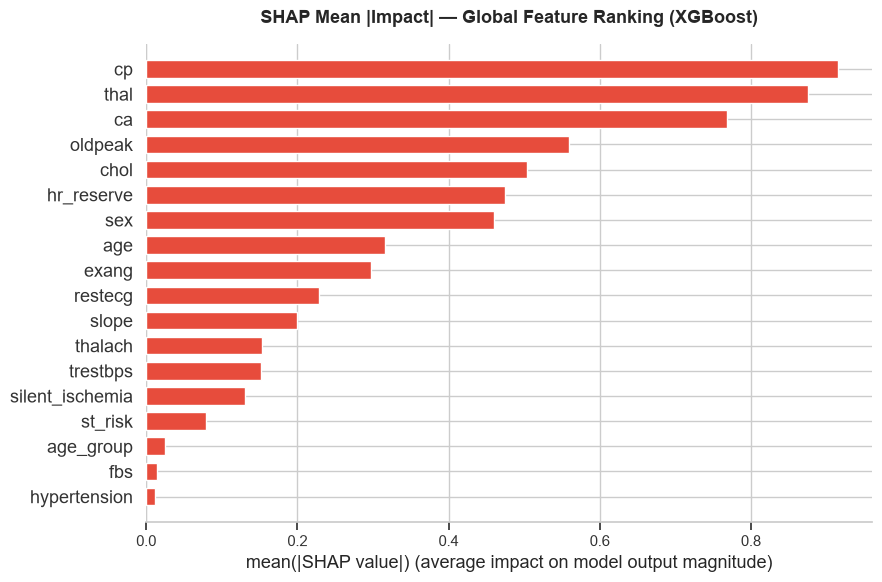


📌  Reading the SHAP beeswarm plot (above):
    • Each row  = one feature
    • Each dot  = one patient in the test set
    • X-axis    = SHAP value (positive = pushes toward disease prediction)
    • Dot color = feature value  (red = high, blue = low)
    • Width     = density of patients at that SHAP value



In [27]:
# SHAP bar chart (mean absolute impact — global ranking)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=list(X.columns),
                  plot_type="bar", show=False,
                  plot_size=None, color="#e74c3c")
plt.title("SHAP Mean |Impact| — Global Feature Ranking (XGBoost)",
          fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("""
📌  Reading the SHAP beeswarm plot (above):
    • Each row  = one feature
    • Each dot  = one patient in the test set
    • X-axis    = SHAP value (positive = pushes toward disease prediction)
    • Dot color = feature value  (red = high, blue = low)
    • Width     = density of patients at that SHAP value
""")


In [28]:
# ── Final Project Summary ─────────────────────────────────────
print("=" * 62)
print("  FINAL PROJECT SUMMARY")
print("=" * 62)
print(f"  Domain      : Healthcare (Cardiovascular Risk Prediction)")
print(f"  Dataset     : UCI Cleveland Heart Disease")
print(f"  Patients    : {len(df_eng)}")
print(f"  Features    : {X.shape[1]}  (13 original + 5 engineered)")
print(f"  Train / Test: {X_train.shape[0]} / {X_test.shape[0]}  (80/20 stratified)")
print()
print("  MODEL RESULTS (Test Set):")
print("  " + "-" * 48)
for name, row in results_df.iterrows():
    marker = "  ← BEST" if name == best else ""
    print(f"  {name:<24}  "
          f"AUC: {row['AUC-ROC']:.4f}  "
          f"F1: {row['F1-Score']:.4f}  "
          f"Acc: {row['Accuracy']:.4f}{marker}")
print("  " + "-" * 48)
print(f"\n  Recommended : {best}")
print(f"  Test AUC    : {results_df.loc[best, 'AUC-ROC']:.4f}")
print(f"  Test F1     : {results_df.loc[best, 'F1-Score']:.4f}")
print(f"  Accuracy    : {results_df.loc[best, 'Accuracy']:.4f}")
print("=" * 62)


  FINAL PROJECT SUMMARY
  Domain      : Healthcare (Cardiovascular Risk Prediction)
  Dataset     : UCI Cleveland Heart Disease
  Patients    : 302
  Features    : 18  (13 original + 5 engineered)
  Train / Test: 241 / 61  (80/20 stratified)

  MODEL RESULTS (Test Set):
  ------------------------------------------------
  Logistic Regression       AUC: 0.8745  F1: 0.8169  Acc: 0.7869
  Random Forest             AUC: 0.8874  F1: 0.8493  Acc: 0.8197  ← BEST
  XGBoost                   AUC: 0.8571  F1: 0.8219  Acc: 0.7869
  ------------------------------------------------

  Recommended : Random Forest
  Test AUC    : 0.8874
  Test F1     : 0.8493
  Accuracy    : 0.8197
